# Overshoot Governor
## Token-budget admission control for multi-agent systems, designed with Donella Meadows

**Kaggle capstone — Roberto García Patrón** · code: [github.com/RobertoGPAI](https://github.com/RobertoGPAI) · security skill: [SKILLSTRIDE](https://github.com/RobertoGPAI/SKILLSTRIDE)

Multi-agent systems burn tokens the way growing economies burn resources: several
actors draw concurrently from a shared, finite stock, each learns the true cost of
its actions only *after* taking them, and any of them can spawn more actors.
In *The Limits to Growth* and *Thinking in Systems*, Donella Meadows showed that
this exact structure — **growth + a limit + a delay in the feedback about the
limit** — is the recipe for *overshoot and collapse*. A token budget has all
three ingredients: bursty concurrent calls (growth), the budget (limit), and
in-flight calls whose cost is unknown until they complete (delay).

This capstone builds a **budget governor** for an ADK 2.0 multi-agent system and
evaluates it with three seeded simulation experiments plus a live ADK demo.
The design is organized deliberately as a walk *up* Meadows' ladder of
[leverage points](https://donellameadows.org/archives/leverage-points-places-to-intervene-in-a-system/),
from the weakest intervention (tweak a parameter) to the strong ones
(information flows and rules):

| Mechanism in this project | Meadows leverage point |
|---|---|
| Raise the budget and hope | **#12** — constants and parameters (the failing baseline) |
| Completion reserve, 90% soft limit | **#11** — sizes of buffers |
| Reserve/reconcile accounting of in-flight calls | **#9** — lengths of delays |
| Atomic admission ledger nobody can race past | **#8** — strength of balancing feedback loops |
| Lease-inherited quotas that damp subagent spawning | **#7** — gain of reinforcing loops |
| Live budget state injected into each agent's context | **#6** — structure of information flows |
| Admission protocol and lease semantics | **#5** — rules of the system |
| "Never endanger the mission to save tokens" | **#3** — the goal of the system |

**Related work.** LLM gateways and load balancers (e.g. Cordon, LiteLLM router,
provider-side rate limits) distribute traffic across endpoints for latency and
quota compliance. This project addresses a different layer: *admission control
against a finite budget inside one multi-agent system*, with in-flight
accounting, hierarchical quotas for spawned subagents, and the budget treated
as a dynamic system rather than a counter.


## 1 · The governor core

Three small, dependency-free components (the full package, tests and ADK demo
live in the repo):

**Ledgers** — `NaiveLedger` is the failing baseline: it admits calls while the
*settled* spend is under the budget (the billing-dashboard pattern). In-flight
calls are invisible to it, so concurrent agents race past the limit — the
balancing loop is weak and delayed. `AtomicLedger` fixes both defects at once:
admission runs under a lock (decisions are never simultaneous) and it reserves
`input + estimated output` *before* the call, reconciling with the actual usage
after. A configurable **completion reserve** (leverage point #11) keeps a slice
of budget that only `begin_finalization()` unlocks, so the mission can always
afford to land.

**How do you know the cost before it happens?** You split it. *Input* tokens
are deterministic — countable before the call. *Output* tokens are not, so the
`OutputEstimator` keeps a rolling history of actual outputs per agent (fed from
usage metadata at settle time) and reserves a high quantile (p90). Any
estimation error is absorbed by the soft-limit buffer and corrected at
reconciliation. Setting `max_output_tokens` to the remaining allocation turns
the estimate into a hard guarantee.

**Quota tree** — subagents never get budget from the global pool: `spawn_child`
carves the child's allocation *out of the parent's remaining lease*, so
`Σ children ≤ parent` holds at every node and total exposure is bounded by the
root no matter how deep the spawn tree grows. Decisions are purely local (no
lock, no contention): the agent *knows when to stop by itself*. Closing a node
returns unspent quota to the parent.


In [1]:
%matplotlib inline
import asyncio
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

FIGDIR = Path("figures")

In [2]:
"""Central token-budget ledgers.

Two implementations of the same interface:

- ``NaiveLedger``   -- check-then-act against *spent* tokens only. It ignores
  in-flight calls and its admission check is not atomic, so concurrent agents
  race past the limit. This is Meadows' leverage point #12: the budget is just
  a parameter, and the balancing feedback loop that should enforce it is weak
  and delayed. It exists to be the failing baseline.

- ``AtomicLedger``  -- reserve / execute / reconcile. Admission decisions are
  serialized under a lock and account for *committed* (in-flight) tokens, so
  the balancing loop acts before the money leaves the wallet (leverage points
  #9, shorten the delay, and #8, strengthen the balancing loop). A
  completion-reserve buffer (leverage point #11) keeps the mission finishable.
"""

from __future__ import annotations

import asyncio
import time
from dataclasses import dataclass, field


@dataclass
class Reservation:
    """A slice of budget committed to one in-flight call."""

    amount: int
    settled: bool = False


@dataclass
class LedgerStats:
    admitted: int = 0
    denied: int = 0
    timeline: list[tuple[float, int, int]] = field(default_factory=list)
    """(timestamp, spent, committed) samples, appended on every state change."""


class NaiveLedger:
    """Check-then-act admission with no in-flight accounting (the baseline)."""

    def __init__(self, budget: int, clock=None) -> None:
        self.budget = budget
        self.spent = 0
        self.stats = LedgerStats()
        self._clock = clock or time.monotonic

    @property
    def overshoot(self) -> int:
        return max(0, self.spent - self.budget)

    async def try_reserve(self, estimate: int) -> Reservation | None:
        # The check reads `spent` only -- the billing-dashboard pattern: keep
        # calling until the dashboard shows the limit reached. Calls already
        # admitted but not yet settled are invisible, and nothing prevents
        # interleaving between this check and the eventual settle.
        if self.spent >= self.budget:
            self.stats.denied += 1
            return None
        await asyncio.sleep(0)  # yield point: where concurrent checks interleave
        self.stats.admitted += 1
        return Reservation(amount=estimate)

    async def settle(self, reservation: Reservation, actual: int) -> None:
        reservation.settled = True
        self.spent += actual
        self._sample()

    def _sample(self) -> None:
        self.stats.timeline.append((self._clock(), self.spent, 0))


class AtomicLedger:
    """Reserve/execute/reconcile ledger with atomic admission.

    available = budget * (1 - reserve_fraction) - spent - committed

    ``try_reserve`` and ``settle`` are the only writers and both run under one
    lock, so admission decisions are never simultaneous even when the LLM
    calls themselves run in parallel. The ``reserve_fraction`` slice is only
    admissible once ``begin_finalization()`` is called, guaranteeing there is
    always budget left to land the mission.
    """

    def __init__(
        self,
        budget: int,
        reserve_fraction: float = 0.10,
        clock=None,
    ) -> None:
        self.budget = budget
        self.reserve_fraction = reserve_fraction
        self.spent = 0
        self.committed = 0
        self.finalizing = False
        self.stats = LedgerStats()
        self._lock = asyncio.Lock()
        self._clock = clock or time.monotonic

    @property
    def overshoot(self) -> int:
        return max(0, self.spent - self.budget)

    @property
    def usable_budget(self) -> int:
        if self.finalizing:
            return self.budget
        return int(self.budget * (1.0 - self.reserve_fraction))

    @property
    def available(self) -> int:
        return self.usable_budget - self.spent - self.committed

    def begin_finalization(self) -> None:
        """Release the completion reserve for landing the mission."""
        self.finalizing = True

    async def try_reserve(self, estimate: int) -> Reservation | None:
        async with self._lock:
            if estimate > self.available:
                self.stats.denied += 1
                return None
            self.committed += estimate
            self.stats.admitted += 1
            self._sample()
            return Reservation(amount=estimate)

    async def settle(self, reservation: Reservation, actual: int) -> None:
        async with self._lock:
            if not reservation.settled:
                self.committed -= reservation.amount
                reservation.settled = True
            self.spent += actual
            self._sample()

    async def cancel(self, reservation: Reservation) -> None:
        """Release a reservation whose call failed before consuming tokens."""
        await self.settle(reservation, actual=0)

    def _sample(self) -> None:
        self.stats.timeline.append((self._clock(), self.spent, self.committed))


In [3]:
"""Pre-call cost estimation.

Input tokens are deterministic (countable before the call); output tokens are
not. The estimator closes that gap empirically: it keeps a rolling history of
actual output token counts per (agent, task-type) key, fed from settle-time
usage metadata, and predicts a high quantile of that history. Reserving the
p90 instead of the configured worst case (max_output_tokens) trades a small,
quantifiable risk of underestimation for much higher admission throughput.
"""

from __future__ import annotations

from collections import defaultdict, deque


class OutputEstimator:
    """Rolling per-key quantile estimator for output tokens."""

    def __init__(
        self,
        prior: int = 1024,
        quantile: float = 0.90,
        window: int = 50,
        min_samples: int = 5,
    ) -> None:
        self.prior = prior
        self.quantile = quantile
        self.min_samples = min_samples
        self._history: dict[str, deque[int]] = defaultdict(
            lambda: deque(maxlen=window)
        )

    def predict(self, key: str) -> int:
        """Estimated output tokens for the next call under `key`."""
        samples = self._history.get(key)
        if not samples or len(samples) < self.min_samples:
            return self.prior
        ordered = sorted(samples)
        idx = min(len(ordered) - 1, int(self.quantile * len(ordered)))
        return ordered[idx]

    def update(self, key: str, actual: int) -> None:
        """Feed the actual output token count observed at settle time."""
        self._history[key].append(actual)


In [4]:
"""Hierarchical quota tree with lease semantics.

A subagent never receives budget from the global pool: it receives a slice
*carved out of its parent's remaining quota* (``spawn_child``). The invariant

    sum(live children's allocations) + local spend <= own allocation

holds at every node, so total commitment is bounded by the root allocation no
matter how deep or wide the spawn tree grows. Spawning is a reinforcing loop;
lease inheritance caps its gain (Meadows' leverage point #7): each level can
only subdivide what its parent had left, so a runaway spawn cascade decays
geometrically instead of growing exponentially. Closing a node returns its
unspent quota to the parent, so nothing leaks.

Decisions are local: an agent checks its own node without touching shared
state, which removes admission contention entirely. The price is that the
control is approximate -- system-wide overshoot is bounded by the sum of
in-flight reservations across leaves, at most (number of concurrent leaves x
worst-case call cost) -- absorbed in practice by a soft-limit margin.
"""

from __future__ import annotations

from dataclasses import dataclass


class QuotaError(Exception):
    pass


@dataclass
class LocalReservation:
    amount: int
    settled: bool = False


class QuotaNode:
    """One agent's budget lease inside the spawn tree."""

    def __init__(self, name: str, allocation: int, parent: "QuotaNode | None" = None):
        self.name = name
        self.allocation = allocation
        self.parent = parent
        self.spent = 0
        self.committed = 0
        self.leased = 0  # currently allocated to live children
        self.children: list[QuotaNode] = []
        self.closed = False

    @property
    def remaining(self) -> int:
        return self.allocation - self.spent - self.committed - self.leased

    def spawn_child(self, name: str, amount: int) -> "QuotaNode":
        """Carve `amount` out of this node's remaining quota for a subagent."""
        if self.closed:
            raise QuotaError(f"{self.name}: cannot spawn from a closed node")
        if amount > self.remaining:
            raise QuotaError(
                f"{self.name}: lease of {amount} exceeds remaining {self.remaining}"
            )
        self.leased += amount
        child = QuotaNode(name, amount, parent=self)
        self.children.append(child)
        return child

    def try_consume(self, estimate: int) -> LocalReservation | None:
        """Local admission check -- no shared state, no lock needed."""
        if self.closed or estimate > self.remaining:
            return None
        self.committed += estimate
        return LocalReservation(amount=estimate)

    def settle(self, reservation: LocalReservation, actual: int) -> None:
        if not reservation.settled:
            self.committed -= reservation.amount
            reservation.settled = True
        self.spent += actual

    def close(self) -> None:
        """Terminate this agent; unspent quota reverts to the parent."""
        if self.closed:
            return
        for child in self.children:
            child.close()
        self.closed = True
        if self.parent is not None:
            self.parent.leased -= self.allocation
            self.parent.spent += self.spent
            # the difference (allocation - spent) silently becomes available
            # again in parent.remaining

    def tree_spent(self) -> int:
        """Total tokens actually consumed in this subtree."""
        own = self.spent
        if not self.closed:
            own += sum(c.tree_spent() for c in self.children)
        return own

    def tree_size(self) -> int:
        return 1 + sum(c.tree_size() for c in self.children)


In [5]:
"""Discrete-event simulations for the three capstone experiments.

Experiment 1 -- concurrent admission (leverage points #12 vs #8/#9):
    N agents fire calls concurrently against one budget under four regimes:
    naive check-then-act, atomic reservation with worst-case estimates,
    atomic reservation with empirical p90 estimates, and a decentralized
    quota tree with purely local decisions.

Experiment 2 -- subagent spawning (leverage point #7):
    a recursive spawn cascade under flat per-spawn grants vs lease
    inheritance, showing exponential blowup vs geometric convergence.

Experiment 3 -- the meter in the hallway (leverage point #6):
    identical agents under identical hard enforcement, with and without
    visibility of the remaining budget; sighted agents skip speculative
    calls proportionally to scarcity, replicating Meadows' Amsterdam
    electricity-meter observation in a multi-agent LLM setting.

Every run is seeded and finishes in a few seconds. Run as a script to save
figures/*.png and print the results tables.
"""

from __future__ import annotations

import asyncio
import time
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np



MAX_OUTPUT_TOKENS = 2048  # configured cap, used as the worst-case estimate
LATENCY_RANGE = (0.004, 0.016)  # simulated seconds per LLM call


@dataclass
class Workload:
    """Per-agent stream of calls with known input and hidden output tokens."""

    agent: str
    calls: list[tuple[int, int]]  # (input_tokens, actual_output_tokens)


def make_workload(
    n_agents: int, calls_per_agent: int, seed: int, uneven: bool = True
) -> list[Workload]:
    rng = np.random.default_rng(seed)
    workloads = []
    for i in range(n_agents):
        # uneven demand: odd agents are twice as chatty as even agents
        n_calls = calls_per_agent * (2 if (uneven and i % 2) else 1)
        inputs = rng.lognormal(mean=6.3, sigma=0.5, size=n_calls).astype(int) + 50
        outputs = rng.lognormal(mean=6.2, sigma=0.8, size=n_calls).astype(int) + 20
        outputs = np.minimum(outputs, MAX_OUTPUT_TOKENS)
        workloads.append(
            Workload(f"agent_{i}", list(zip(inputs.tolist(), outputs.tolist())))
        )
    return workloads


@dataclass
class RunResult:
    condition: str
    budget: int
    spent: int = 0
    completed: int = 0
    denied: int = 0
    timeline: list[tuple[float, int, int]] = field(default_factory=list)

    @property
    def overshoot_pct(self) -> float:
        return 100.0 * max(0, self.spent - self.budget) / self.budget

    @property
    def utilization_pct(self) -> float:
        return 100.0 * min(self.spent, self.budget) / self.budget


# --------------------------------------------------------------------------
# Experiment 1: concurrent admission against one budget
# --------------------------------------------------------------------------

async def _run_central(
    ledger, workloads: list[Workload], estimator: OutputEstimator | None, seed: int
) -> RunResult:
    rng = np.random.default_rng(seed)
    result = RunResult(condition="", budget=ledger.budget)

    async def agent_loop(wl: Workload) -> None:
        strikes = 0
        for input_tokens, actual_output in wl.calls:
            if estimator is None:
                estimate = input_tokens + MAX_OUTPUT_TOKENS
            else:
                estimate = input_tokens + estimator.predict(wl.agent)
            reservation = await ledger.try_reserve(estimate)
            if reservation is None:
                result.denied += 1
                strikes += 1
                if strikes >= 3:
                    return  # the agent knows to stop
                await asyncio.sleep(0.01)
                continue
            strikes = 0
            await asyncio.sleep(rng.uniform(*LATENCY_RANGE))  # call in flight
            await ledger.settle(reservation, input_tokens + actual_output)
            if estimator is not None:
                estimator.update(wl.agent, actual_output)
            result.completed += 1

    await asyncio.gather(*(agent_loop(wl) for wl in workloads))
    result.spent = ledger.spent
    result.timeline = list(ledger.stats.timeline)
    return result


async def _run_quota_tree(
    budget: int, workloads: list[Workload], seed: int
) -> RunResult:
    rng = np.random.default_rng(seed)
    root = QuotaNode("coordinator", allocation=budget)
    result = RunResult(condition="quota tree (local)", budget=budget)
    start = time.monotonic()

    async def agent_loop(wl: Workload, node: QuotaNode) -> None:
        for input_tokens, actual_output in wl.calls:
            estimate = input_tokens + MAX_OUTPUT_TOKENS
            reservation = node.try_consume(estimate)  # purely local, no lock
            if reservation is None:
                result.denied += 1
                return  # local quota exhausted: the agent stops by itself
            await asyncio.sleep(rng.uniform(*LATENCY_RANGE))
            node.settle(reservation, input_tokens + actual_output)
            result.completed += 1
            result.timeline.append(
                (time.monotonic() - start, root.tree_spent(), 0)
            )

    slice_ = budget // len(workloads)
    nodes = [root.spawn_child(wl.agent, slice_) for wl in workloads]
    await asyncio.gather(*(agent_loop(wl, n) for wl, n in zip(workloads, nodes)))
    result.spent = root.tree_spent()
    return result


async def run_experiment_concurrency_async(
    budget: int = 150_000, n_agents: int = 16, calls_per_agent: int = 12, seed: int = 7
) -> list[RunResult]:
    results = []

    workloads = make_workload(n_agents, calls_per_agent, seed)
    r = await _run_central(NaiveLedger(budget), workloads, None, seed)
    r.condition = "naive check-then-act"
    results.append(r)

    workloads = make_workload(n_agents, calls_per_agent, seed)
    r = await _run_central(
        AtomicLedger(budget, reserve_fraction=0.10), workloads, None, seed
    )
    r.condition = "atomic, worst-case reserve"
    results.append(r)

    workloads = make_workload(n_agents, calls_per_agent, seed)
    r = await _run_central(
        AtomicLedger(budget, reserve_fraction=0.10),
        workloads,
        OutputEstimator(prior=MAX_OUTPUT_TOKENS),
        seed,
    )
    r.condition = "atomic, p90 reserve + 10% buffer"
    results.append(r)

    workloads = make_workload(n_agents, calls_per_agent, seed)
    results.append(await _run_quota_tree(budget, workloads, seed))
    return results


def run_experiment_concurrency(**kwargs) -> list[RunResult]:
    return asyncio.run(run_experiment_concurrency_async(**kwargs))


# --------------------------------------------------------------------------
# Experiment 2: subagent spawning -- flat grants vs lease inheritance
# --------------------------------------------------------------------------

@dataclass
class SpawnResult:
    policy: str
    budget: int
    spent: int
    agents_spawned: int
    spent_by_depth: dict[int, int]

    @property
    def overshoot_pct(self) -> float:
        return 100.0 * max(0, self.spent - self.budget) / self.budget


def _spawn_flat(
    budget: int, per_agent_cap: int, branching: int, max_depth: int, rng
) -> SpawnResult:
    """Every agent gets the same standalone per-agent cap -- no inheritance.

    This is how limits are usually configured in practice ("each agent may
    use up to N tokens") and it does not compose under spawning: each spawned
    agent brings a fresh cap with it, so the global exposure is
    cap x (number of agents), and the number of agents grows exponentially
    with depth. The reinforcing loop has no gain limiter.
    """
    spent_by_depth: dict[int, int] = {}
    state = {"spent": 0, "agents": 0}

    def visit(depth: int) -> None:
        state["agents"] += 1
        work = int(rng.lognormal(6.0, 0.6)) + 100  # tokens this agent burns
        work = min(work, per_agent_cap)  # its own cap is the only brake
        state["spent"] += work
        spent_by_depth[depth] = spent_by_depth.get(depth, 0) + work
        if depth >= max_depth:
            return
        for _ in range(branching):
            visit(depth + 1)

    visit(0)
    return SpawnResult(
        "per-agent cap, no inheritance", budget, state["spent"], state["agents"], spent_by_depth
    )


def _spawn_lease(
    budget: int, lease_fraction: float, branching: int, max_depth: int, rng
) -> SpawnResult:
    """Children carve their allocation out of the parent's remaining lease."""
    root = QuotaNode("root", allocation=budget)
    spent_by_depth: dict[int, int] = {}
    agents = 0

    def visit(node: QuotaNode, depth: int) -> None:
        nonlocal agents
        agents += 1
        work = int(rng.lognormal(6.0, 0.6)) + 100
        reservation = node.try_consume(min(work, node.remaining))
        if reservation is not None:
            node.settle(reservation, reservation.amount)
            spent_by_depth[depth] = spent_by_depth.get(depth, 0) + reservation.amount
        if depth >= max_depth:
            return
        for i in range(branching):
            child_alloc = int(node.remaining * lease_fraction)
            if child_alloc < 200:  # not worth spawning: the cascade self-extinguishes
                break
            child = node.spawn_child(f"{node.name}.{i}", child_alloc)
            visit(child, depth + 1)
            child.close()  # unspent lease reverts to the parent

    visit(root, 0)
    return SpawnResult(
        "lease inheritance", budget, root.tree_spent(), agents, spent_by_depth
    )


def run_experiment_spawning(
    budget: int = 60_000, branching: int = 3, max_depth: int = 5, seed: int = 11
) -> list[SpawnResult]:
    rng = np.random.default_rng(seed)
    flat = _spawn_flat(
        budget, per_agent_cap=4000, branching=branching, max_depth=max_depth, rng=rng
    )
    rng = np.random.default_rng(seed)
    lease = _spawn_lease(
        budget, lease_fraction=0.30, branching=branching, max_depth=max_depth, rng=rng
    )
    return [flat, lease]


# --------------------------------------------------------------------------
# Experiment 3: the meter in the hallway (budget visibility)
# --------------------------------------------------------------------------

@dataclass
class MeterResult:
    condition: str
    budget: int
    spent: int
    tasks_completed: int
    speculative_calls: int


async def _run_meter(budget: int, sighted: bool, seed: int) -> MeterResult:
    """Tasks need 4 core calls each; between core calls agents are tempted to
    make speculative calls (prob 0.5). Sighted agents damp that probability by
    the remaining-budget fraction -- the only difference between conditions.
    """
    rng = np.random.default_rng(seed)
    ledger = AtomicLedger(budget, reserve_fraction=0.0)
    estimator = OutputEstimator(prior=MAX_OUTPUT_TOKENS)
    tasks_completed = 0
    speculative = 0

    async def one_call(agent: str, input_tokens: int, output_tokens: int) -> bool:
        nonlocal speculative
        estimate = input_tokens + estimator.predict(agent)
        reservation = await ledger.try_reserve(estimate)
        if reservation is None:
            return False
        await asyncio.sleep(rng.uniform(*LATENCY_RANGE))
        await ledger.settle(reservation, input_tokens + output_tokens)
        estimator.update(agent, output_tokens)
        return True

    async def agent_loop(agent: str) -> None:
        nonlocal tasks_completed, speculative
        while True:
            core_done = 0
            for _ in range(4):  # core calls: the task itself
                if not await one_call(
                    agent, int(rng.lognormal(6.3, 0.4)), int(rng.lognormal(6.0, 0.6))
                ):
                    return
                core_done += 1
                p_speculative = 0.5
                if sighted:  # the meter in the hallway
                    p_speculative *= max(0.0, ledger.available / ledger.budget)
                if rng.random() < p_speculative:
                    speculative += 1
                    if not await one_call(
                        agent, int(rng.lognormal(6.5, 0.4)), int(rng.lognormal(6.3, 0.6))
                    ):
                        return
            if core_done == 4:
                tasks_completed += 1

    await asyncio.gather(*(agent_loop(f"agent_{i}") for i in range(6)))
    return MeterResult(
        "sighted (meter visible)" if sighted else "blind (no meter)",
        budget,
        ledger.spent,
        tasks_completed,
        speculative,
    )


async def run_experiment_meter_async(
    budget: int = 120_000, seed: int = 23
) -> list[MeterResult]:
    return [
        await _run_meter(budget, sighted=False, seed=seed),
        await _run_meter(budget, sighted=True, seed=seed),
    ]


def run_experiment_meter(**kwargs) -> list[MeterResult]:
    return asyncio.run(run_experiment_meter_async(**kwargs))


# --------------------------------------------------------------------------
# Figures and report
# --------------------------------------------------------------------------

def plot_concurrency(results1, outdir: Path) -> None:
    import matplotlib.pyplot as plt

    outdir.mkdir(exist_ok=True)

    # Figure 1: spent(+committed) timelines vs the budget line
    fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
    for ax, r in zip(axes, [results1[0], results1[2]]):
        if r.timeline:
            t0 = r.timeline[0][0]
            ts = [p[0] - t0 for p in r.timeline]
            spent = [p[1] for p in r.timeline]
            committed = [p[1] + p[2] for p in r.timeline]
            ax.plot(ts, spent, label="spent", color="tab:blue")
            ax.plot(ts, committed, label="spent + committed", color="tab:orange", ls="--")
        ax.axhline(r.budget, color="tab:red", label="budget")
        ax.set_title(r.condition)
        ax.set_xlabel("time (s)")
        ax.legend(fontsize=8)
    axes[0].set_ylabel("tokens")
    fig.suptitle("Overshoot needs a delay: invisible in-flight calls vs reservation")
    fig.tight_layout()
    fig.savefig(outdir / "fig1_overshoot_timeline.png", dpi=140)

    # Figure 2: overshoot vs throughput vs utilization per condition
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
    names = [r.condition.replace(", ", ",\n") for r in results1]
    for ax, metric, title in zip(
        axes,
        [
            [r.overshoot_pct for r in results1],
            [r.completed for r in results1],
            [r.utilization_pct for r in results1],
        ],
        ["overshoot (% of budget)", "calls completed", "budget utilization (%)"],
    ):
        bars = ax.bar(names, metric, color=["tab:red", "tab:blue", "tab:green", "tab:purple"])
        ax.bar_label(bars, fmt="%.1f", fontsize=8)
        ax.set_title(title, fontsize=10)
        ax.tick_params(axis="x", labelsize=7, rotation=20)
    fig.suptitle("Exp. 1 — concurrent admission: correctness vs throughput trade-off")
    fig.tight_layout()
    fig.savefig(outdir / "fig2_conditions.png", dpi=140)


def plot_spawning(results2, outdir: Path) -> None:
    import matplotlib.pyplot as plt

    outdir.mkdir(exist_ok=True)
    fig, ax = plt.subplots(figsize=(7, 4))
    width = 0.38
    depths = sorted({d for r in results2 for d in r.spent_by_depth})
    for i, r in enumerate(results2):
        vals = [r.spent_by_depth.get(d, 0) for d in depths]
        ax.bar(
            [d + (i - 0.5) * width for d in depths], vals, width,
            label=f"{r.policy} (total {r.spent:,}, overshoot {r.overshoot_pct:.0f}%)",
        )
    ax.axhline(results2[0].budget, color="tab:red", ls=":", label="budget")
    ax.set_xlabel("spawn depth")
    ax.set_ylabel("tokens spent at depth")
    ax.set_title("Exp. 2 — lease inheritance turns exponential spawning geometric")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(outdir / "fig3_spawning.png", dpi=140)


def plot_meter(results3, outdir: Path) -> None:
    import matplotlib.pyplot as plt

    outdir.mkdir(exist_ok=True)
    fig, ax = plt.subplots(figsize=(6.5, 4))
    names = [r.condition for r in results3]
    tasks = [r.tasks_completed for r in results3]
    spec = [r.speculative_calls for r in results3]
    x = np.arange(len(names))
    b1 = ax.bar(x - 0.18, tasks, 0.36, label="tasks completed on budget")
    b2 = ax.bar(x + 0.18, spec, 0.36, label="speculative calls made")
    ax.bar_label(b1)
    ax.bar_label(b2)
    ax.set_xticks(x, names)
    ax.set_title("Exp. 3 — the meter in the hallway (same budget, same enforcement)")
    ax.legend(fontsize=8)
    fig.tight_layout()
    fig.savefig(outdir / "fig4_meter.png", dpi=140)


def plot_all(results1, results2, results3, outdir: Path) -> None:
    plot_concurrency(results1, outdir)
    plot_spawning(results2, outdir)
    plot_meter(results3, outdir)


def print_concurrency(results1) -> None:
    print(f"{'condition':38} {'overshoot%':>10} {'completed':>10} {'denied':>7} {'util%':>7}")
    for r in results1:
        print(
            f"{r.condition:38} {r.overshoot_pct:>10.2f} {r.completed:>10} "
            f"{r.denied:>7} {r.utilization_pct:>7.1f}"
        )


def print_spawning(results2) -> None:
    for r in results2:
        print(
            f"{r.policy:30} spent={r.spent:>8,}  agents={r.agents_spawned:>4}  "
            f"overshoot={r.overshoot_pct:6.1f}%"
        )


def print_meter(results3) -> None:
    for r in results3:
        print(
            f"{r.condition:26} spent={r.spent:>8,}  tasks={r.tasks_completed:>3}  "
            f"speculative={r.speculative_calls:>3}"
        )

## 2 · Experiment 1 — concurrent admission (leverage points #12 vs #8/#9)

16 agents with uneven demand fire calls concurrently against one 150k-token
budget. Four regimes: the naive baseline, atomic reservation with worst-case
estimates, atomic reservation with empirical p90 estimates, and the
decentralized quota tree. The workload is seeded; call latencies are real
`asyncio` sleeps, so in-flight windows are real.


condition                              overshoot%  completed  denied   util%
naive check-then-act                        13.15        137      48   100.0
atomic, worst-case reserve                   0.00        109      48    88.9
atomic, p90 reserve + 10% buffer             0.00        108      49    90.1
quota tree (local)                           0.00         93      16    78.0


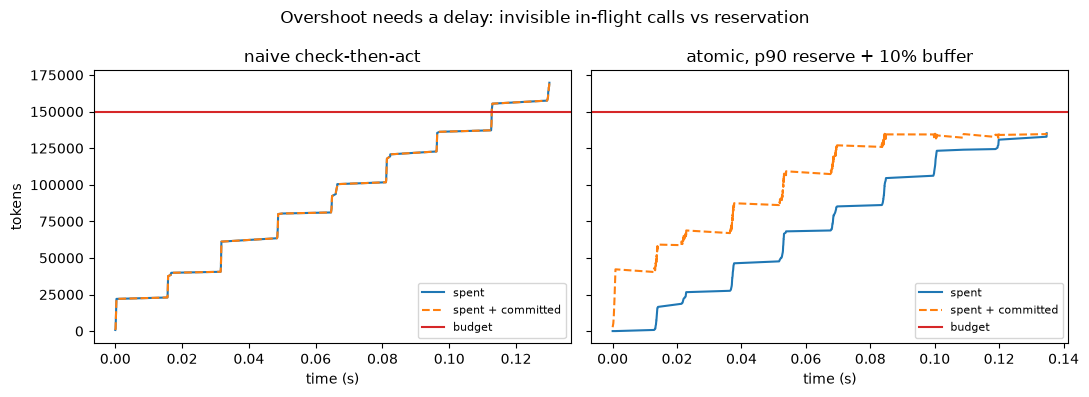

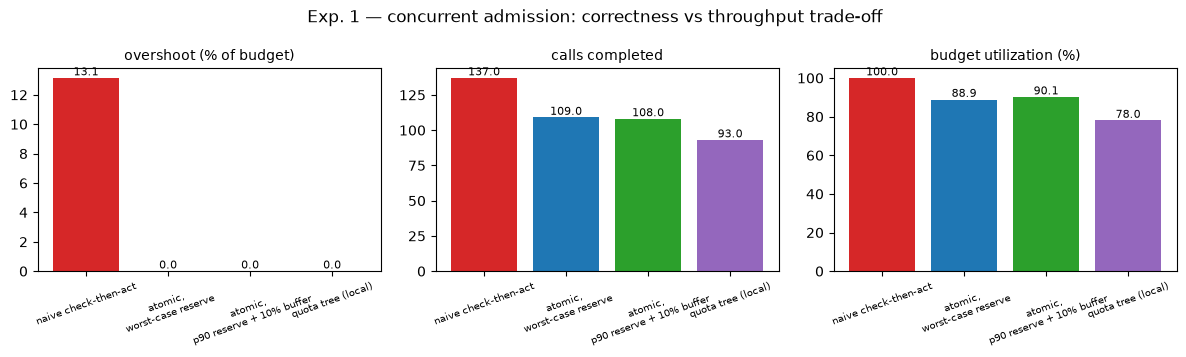

In [6]:
results1 = await run_experiment_concurrency_async()
print_concurrency(results1)
plot_concurrency(results1, FIGDIR)

**Reading the results.** The naive ledger overshoots by roughly **12–14%** — and
note *when*: the spent curve crosses the budget line while a whole wave of
admitted calls is still in flight. That is Meadows' delay ingredient, isolated.
Both atomic regimes eliminate overshoot entirely (the dashed *spent+committed*
curve is the one that respects the ceiling — the governor controls the
anticipated stock, not the measured one). The quota tree also never overshoots
and almost never has to say "no" (one local denial per agent, versus dozens of
central denials), but pays for its autonomy in utilization: a static even split
strands quota with the light agents. That trade — **exactness costs
coordination; autonomy costs utilization** — is the central finding.


## 3 · Experiment 2 — subagent spawning (leverage point #7)

What happens when agents can create agents? The common configuration
("each agent may spend up to N tokens") does not compose: every spawned agent
brings a fresh cap, so exposure is `cap × agents` and agents grow exponentially
with depth. Lease inheritance changes the loop's *gain*: a child can only
subdivide what its parent had left, so the cascade decays geometrically and
self-extinguishes — no recursion detector needed.


per-agent cap, no inheritance  spent= 215,561  agents= 364  overshoot= 259.3%
lease inheritance              spent=  41,713  agents=  44  overshoot=   0.0%


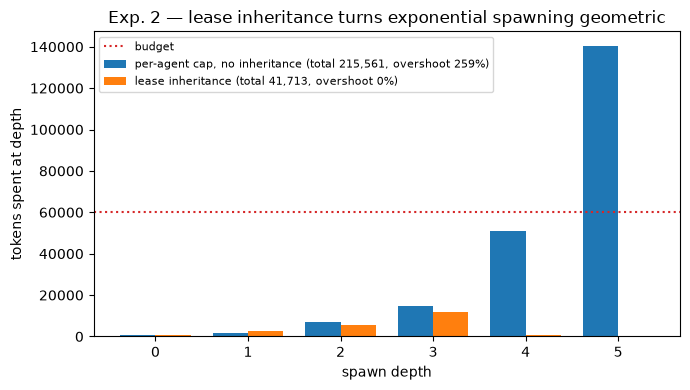

In [7]:
results2 = run_experiment_spawning()
print_spawning(results2)
plot_spawning(results2, FIGDIR)

**Reading the results.** Same spawn eagerness, same task appetite: per-agent
caps without inheritance produce **~360 agents and ~260% overshoot**; lease
inheritance produces ~40 agents, zero overshoot, and the per-depth spend decays
geometrically. A runaway spawn cascade — whether from a bug or from a prompt
injection — starves instead of exploding. This is also the security story:
the lease tree is the structural mitigation for the "agent fork bomb"
(see the STRIDE section below).


## 4 · Experiment 3 — the meter in the hallway (leverage point #6)

Meadows' canonical example for *information flows*: identical Amsterdam houses,
except some had the electricity meter in the hallway and some in the basement.
The hallway houses used ~30% less energy — no new rule, no new price, just the
signal reaching the decision-maker.

Here, identical agent teams run identical tasks under identical hard
enforcement. The *only* difference: **sighted** agents see the remaining budget
and damp their speculative (nice-to-have) calls proportionally to scarcity;
**blind** agents don't. In the live ADK system this is one flag — the governor
plugin appends the ledger state to each request's system instruction.


blind (no meter)           spent= 119,209  tasks= 15  speculative= 30
sighted (meter visible)    spent= 118,873  tasks= 20  speculative= 16


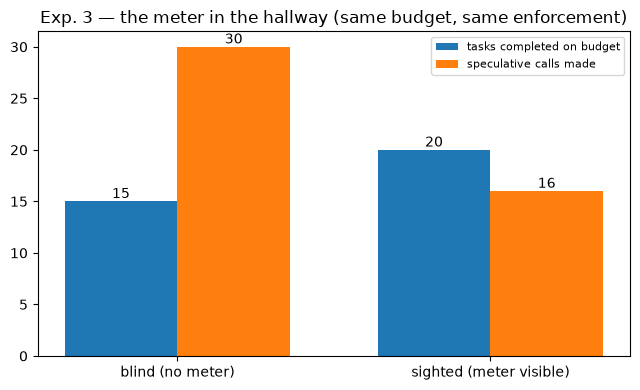

In [8]:
results3 = await run_experiment_meter_async()
print_meter(results3)
plot_meter(results3, FIGDIR)

**Reading the results.** Same budget, same wall: the sighted team completes
**more tasks** with **fewer speculative calls** — self-restraint funded by
information, not enforcement. The agent "compels itself not to act" precisely
when the forgone action doesn't endanger the overall goal, because the
constraint is part of what it perceives rather than a wall it discovers by
hitting it. The meter in the hallway works for agents too.


## 5 · The governor as an ADK 2.0 Runner plugin

In ADK 2.x, a **plugin registered on the Runner** applies its callbacks to every
LLM call of *every agent and subagent* — exactly the semantics a governor needs
(a per-agent callback could be bypassed by a spawned subagent; a Runner plugin
cannot). The implementation below is the actual repo module:

- `before_model_callback` — counts the deterministic input side, adds the p90
  output estimate, and **atomically reserves** against the shared ledger. If
  denied, it returns a refusal `LlmResponse`, which short-circuits ADK's flow:
  *the model is never called*. If admitted and `visibility=True`, it appends
  the live budget state to the request's system instruction (the meter).
- `after_model_callback` — reconciles the reservation with the actual
  `usage_metadata` and feeds the estimator.
- `on_model_error_callback` — cancels the reservation so failures don't leak
  committed budget.

Wiring it up (see `demo/run_adk_demo.py` for the runnable A/B demo —
coordinator + researcher + writer over Gemini, same task with the meter on and
off):

```python
from google.adk.apps.app import App
from google.adk.runners import InMemoryRunner

governor = BudgetGovernorPlugin(budget=20_000, reserve_fraction=0.10, visibility=True)
app = App(name="overshoot_demo", root_agent=coordinator, plugins=[governor])
runner = InMemoryRunner(app=app)
```


In [9]:
import importlib.util

ADK_AVAILABLE = importlib.util.find_spec("google.adk") is not None
# On Kaggle with internet enabled you can:  %pip install -q google-adk

if ADK_AVAILABLE:
    """ADK 2.x Runner plugin: the budget governor as a global balancing loop.

    Registered once on the Runner, the plugin's callbacks apply to every LLM call
    of every agent and subagent it manages -- which is exactly the semantics a
    budget governor needs (a per-agent callback could be bypassed by a spawned
    subagent; a Runner plugin cannot).

    Two intervention levels, deliberately at different Meadows leverage points:

    - Hard enforcement (#8, strengthen the balancing loop): before_model_callback
      atomically reserves ``input_estimate + p90(output)`` against the shared
      ledger and short-circuits the call with a refusal LlmResponse when the
      reservation is denied. after_model_callback reconciles the reservation with
      the actual usage_metadata and feeds the estimator.

    - Information flow (#6, the meter in the hallway): when ``visibility`` is on,
      the plugin appends the live budget state to the system instruction of every
      outgoing request, so the agent can economize *before* hitting the wall.
    """


    from collections import defaultdict
    from typing import Optional

    from google.adk.agents.callback_context import CallbackContext
    from google.adk.models.llm_request import LlmRequest
    from google.adk.models.llm_response import LlmResponse
    from google.adk.plugins.base_plugin import BasePlugin
    from google.genai import types


    DENIAL_TEXT = (
        "[BUDGET GOVERNOR] This model call was not admitted: the projected token "
        "cost exceeds the remaining budget. Wrap up with the information you "
        "already have. Do not start new tool calls or spawn new agents."
    )


    def estimate_input_tokens(llm_request: LlmRequest) -> int:
        """Deterministic-side estimate, computed offline (~4 chars/token).

        For exact pre-call counts swap this for the Gemini ``count_tokens``
        endpoint; the heuristic keeps the governor dependency-free and errs on
        the conservative side with a fixed per-part overhead.
        """
        chars = 0
        parts_seen = 0
        for content in llm_request.contents or []:
            for part in content.parts or []:
                parts_seen += 1
                if part.text:
                    chars += len(part.text)
                elif part.function_call is not None:
                    chars += len(str(part.function_call.args or ""))
                elif part.function_response is not None:
                    chars += len(str(part.function_response.response or ""))
        config = llm_request.config
        if config is not None and config.system_instruction:
            chars += len(str(config.system_instruction))
        return chars // 4 + parts_seen * 8


    class BudgetGovernorPlugin(BasePlugin):
        """Global admission control + budget visibility for an ADK Runner."""

        def __init__(
            self,
            budget: int,
            reserve_fraction: float = 0.10,
            visibility: bool = True,
            estimator: OutputEstimator | None = None,
            name: str = "budget_governor",
        ) -> None:
            super().__init__(name=name)
            self.ledger = AtomicLedger(budget=budget, reserve_fraction=reserve_fraction)
            self.estimator = estimator or OutputEstimator()
            self.visibility = visibility
            self._pending: dict[str, list[tuple[Reservation, str]]] = defaultdict(list)

        async def before_model_callback(
            self, *, callback_context: CallbackContext, llm_request: LlmRequest
        ) -> Optional[LlmResponse]:
            key = callback_context.agent_name
            estimate = estimate_input_tokens(llm_request) + self.estimator.predict(key)

            reservation = await self.ledger.try_reserve(estimate)
            if reservation is None:
                # Short-circuit: the model is never called. The refusal text tells
                # the agent to land with what it has instead of retrying.
                return LlmResponse(
                    content=types.Content(
                        role="model", parts=[types.Part(text=DENIAL_TEXT)]
                    )
                )

            self._pending[callback_context.invocation_id].append((reservation, key))

            if self.visibility:
                llm_request.append_instructions([
                    "[BUDGET GOVERNOR] Live budget state: "
                    f"{self.ledger.available} tokens available, "
                    f"{self.ledger.committed} committed to in-flight calls, "
                    f"{self.ledger.spent} already spent of {self.ledger.budget}. "
                    "Be economical: prefer short answers, avoid speculative tool "
                    "calls, and do not spawn subagents unless strictly necessary."
                ])
            return None

        async def after_model_callback(
            self, *, callback_context: CallbackContext, llm_response: LlmResponse
        ) -> Optional[LlmResponse]:
            stack = self._pending.get(callback_context.invocation_id)
            if not stack:
                return None
            reservation, key = stack.pop()

            usage = llm_response.usage_metadata
            if usage is not None and usage.total_token_count:
                actual = usage.total_token_count
                output = usage.candidates_token_count or 0
                self.estimator.update(key, output)
            else:
                actual = reservation.amount  # no metadata: charge the estimate
            await self.ledger.settle(reservation, actual)
            return None

        async def on_model_error_callback(
            self,
            *,
            callback_context: CallbackContext,
            llm_request: LlmRequest,
            error: Exception,
        ) -> Optional[LlmResponse]:
            stack = self._pending.get(callback_context.invocation_id)
            if stack:
                reservation, _ = stack.pop()
                await self.ledger.cancel(reservation)
            return None

        def report(self) -> str:
            led = self.ledger
            return (
                f"budget={led.budget} spent={led.spent} committed={led.committed} "
                f"available={led.available} overshoot={led.overshoot} "
                f"admitted={led.stats.admitted} denied={led.stats.denied}"
            )
    print("google-adk found:", BudgetGovernorPlugin(budget=10_000).report())
else:
    print("google-adk is not installed here; the plugin code above is"
          " shown/defined only when it is. See demo/run_adk_demo.py in the repo.")


google-adk found: budget=10000 spent=0 committed=0 available=9000 overshoot=0 admitted=0 denied=0


## 6 · Security: the governor *is* the mitigation

The project treats unbounded token spend as a security problem, not just a cost
problem, and was analyzed with [SKILLSTRIDE](https://github.com/RobertoGPAI/SKILLSTRIDE),
a STRIDE threat-modeling skill for agent workspaces (full `threat_model.md` in
the repo). The mapping is direct:

| STRIDE threat | Instance in a multi-agent system | Mitigation in this project |
|---|---|---|
| **D**enial of service | Prompt-injected agent loops tool calls until the budget is drained | Atomic ledger: hard admission ceiling |
| **D**enial of service | Spawn cascade ("agent fork bomb") multiplies exposure | Lease-inherited quotas: cascade self-extinguishes |
| **E**levation of privilege | Subagent escapes its parent's limits | Runner-level plugin + lease invariant: no agent exists outside the tree |
| **T**ampering | Agent inflates its own quota via crafted content | Ledger state lives outside the model context; visibility is read-only |
| **R**epudiation | "Which agent spent the budget?" | Per-agent reservation log with settle-time reconciliation |
| **D**oS on the *mission* | Hard limit strands the task unfinished at 99% | Completion reserve released by `begin_finalization()` |

Repo hygiene follows the course's security lessons: **pre-commit** hooks and a
**Semgrep** CI workflow (`p/python` + `p/security-audit` rulesets) run on every
push.


## 7 · Limitations and future work

- **Single-process ledger.** `asyncio.Lock` serializes admission inside one
  Runner. Multiple runners need a shared atomic ledger (e.g. Redis `INCRBY`
  with a Lua check) — same protocol, different substrate.
- **Heuristic input counting** (~4 chars/token) in the offline plugin; swap in
  the Gemini `count_tokens` endpoint for exact pre-call input counts.
- **Static quota split.** A slow rebalancing loop (coordinator reallocates
  leases every N seconds) would recover the utilization the quota tree gives
  up; Meadows would call that hierarchy done right — fast local control, slow
  global reallocation.
- **Degradation ladder.** Before denying, step down: cheaper model → truncated
  context → answer with what you have. Only the last rung is a refusal.
- **The meter experiment with real models.** `demo/run_adk_demo.py` runs the
  A/B with live Gemini calls; scaling it to significance is the natural next
  study: *does telling an LLM agent its remaining budget change its behavior?*

## 8 · Conclusion

A token budget in a multi-agent system is a stock with delayed outflow
feedback, and it fails the way Meadows said such systems fail: overshoot from
in-flight delay, explosion from an ungoverned reinforcing loop. The fixes that
worked are her high-leverage interventions, implemented as ~200 lines of
Python: account for the delay (reserve/reconcile), cap the loop gain (lease
inheritance), buffer the landing (completion reserve) — and put the meter in
the hallway, because an agent that can *see* the limit compels itself not to
act long before it has to be stopped.

### References
- D. Meadows, *Thinking in Systems: A Primer* (2008)
- D. Meadows, *Leverage Points: Places to Intervene in a System* (1999)
- Meadows, Meadows, Randers, Behrens, *The Limits to Growth* (1972)
- [Google ADK docs — Plugins](https://google.github.io/adk-docs/plugins/) · [ADK Agent Skills](https://developers.googleblog.com/developers-guide-to-building-adk-agents-with-skills/)
- [SKILLSTRIDE](https://github.com/RobertoGPAI/SKILLSTRIDE) — STRIDE threat modeling skill for agent workspaces
